# Config

This section showcases how to use the [datachart.config](../../../references/config/) module to customize the global style of the `datachart` package: applying a theme, changing single attributes, scoping a change to one block, and saving a look to a file so it can be shared or reloaded.

Let's start by importing the necessary functions to help us work with the `datachart.config` module.

In [1]:
from datachart.config import config

In [2]:
from datachart.charts import BarChart
from datachart.constants import FIG_SIZE, THEME

The `config` instance is a global configuration that the users can interact with. It allows them to customize the global style of the `datachart` package.

Furthermore, the instance is of the [datachart.config.Config](../../../references/config/#datachart.config.Config) class.

## The Configuration Instance

The instance holds one style attribute per key of [StyleAttrs](../../../references/typings/#datachart.typings.StyleAttrs) and the name of the active theme. Read an attribute with `config.get` or by indexing:

In [3]:
config.get("font_general_size"), config["color_general_multiple"]

(10, ['#4E79A7', '#F28E2B', '#59A14F', '#E15759', '#B07AA1', '#76B7B2'])

In [4]:
config.theme

'default'

The attribute names are the keys of the live configuration; the reference page documents each one:

In [5]:
len(config.config), list(config.config)[:5]

(274,
 ['color_general_singular',
  'color_general_multiple',
  'color_parallel_hue',
  'color_parallel_hue_continuous',
  'muted_color'])

Charts read the configuration when they are built, so every change below applies to the charts created after it. The examples use the heights of the five tallest mountains:

In [6]:
MOUNTAINS = [
    {"label": "Everest", "y": 8849},
    {"label": "K2", "y": 8611},
    {"label": "Kangchenjunga", "y": 8586},
    {"label": "Lhotse", "y": 8516},
    {"label": "Makalu", "y": 8485},
]


def mountains(title):
    return BarChart(
        data=MOUNTAINS,
        title=title,
        ylabel="Height [m]",
        ymin=8000,
        figsize=FIG_SIZE.FULL_SHORT,
    )

## Customizing the Configuration

| Task                                          | Method                          | Section                                          |
| :-------------------------------------------- | :------------------------------ | :----------------------------------------------- |
| Switch the look of every chart                | `set_theme`, `list_themes`      | [Applying a Theme](#applying-a-theme)            |
| Change single attributes                      | `update_config`                 | [Updating Attributes](#updating-attributes)      |
| Change the style for one block only           | `override`, `using_theme`       | [Scoping a Change](#scoping-a-change)            |
| Share a look as a file and load it back       | `save_theme`, `load_theme`      | [Theme Files](#theme-files)                      |
| Return to the default theme                   | `reset_config`                  | [Resetting](#resetting)                          |

### Applying a Theme

`list_themes` returns every name `set_theme` accepts: the predefined themes from [THEME](../../../references/constants/#datachart.constants.THEME) plus any theme registered with `register_theme` or `load_theme`.

In [7]:
config.list_themes()

['default', 'greyscale', 'ink', 'hatch', 'minimal', 'material', 'sketch']

Applying a theme replaces the whole configuration and updates the active theme name; see the [themes guide](../themes/) for the predefined themes and for registering your own.

In [8]:
config.set_theme(THEME.MINIMAL)
config.theme

'minimal'

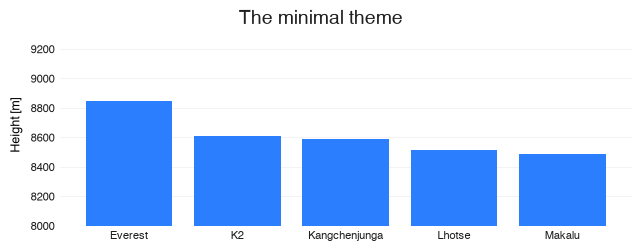

In [9]:
mountains("The minimal theme").show()

### Updating Attributes

`update_config` changes individual attributes on top of the active theme. The change persists until the next `set_theme` or `reset_config`; unknown attribute names are skipped with a warning.

Attributes that take a palette also accept a single color, used for every series that asks for one. The color below applies to charts whose datasets share one coordinate space, which is what every chart does unless `subplots` is on; see [ColorStyleAttrs](../../../references/typings/#datachart.typings.ColorStyleAttrs) for the attribute that covers the subplot case.

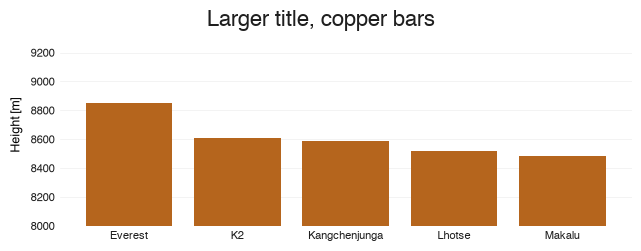

In [10]:
config.update_config({"font_title_size": 16, "color_general_multiple": "#B5651D"})
mountains("Larger title, copper bars").show()

### Scoping a Change

A scope is a temporary style change that lasts for one `with` block: the configuration that entered the block is restored when it ends, also when the block raises. Any `set_theme` or `update_config` performed inside the block is discarded at exit.

`override` scopes attribute overrides, taking keyword arguments or a dictionary:

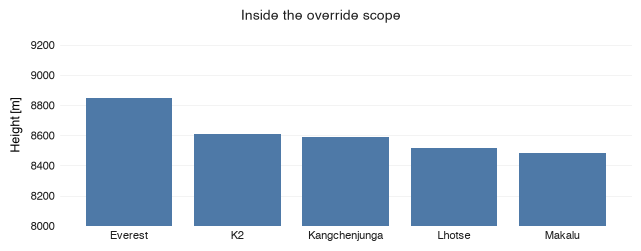

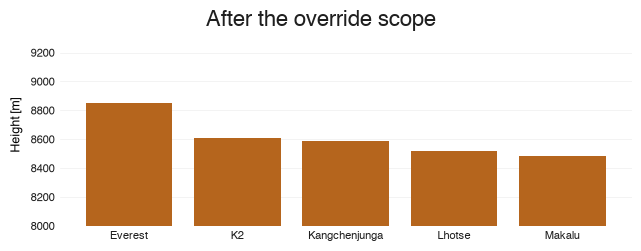

In [11]:
with config.override(font_title_size=10, color_general_multiple="#4E79A7"):
    mountains("Inside the override scope").show()

mountains("After the override scope").show()

`using_theme` scopes a whole theme and restores the active theme name as well:

inside: ink


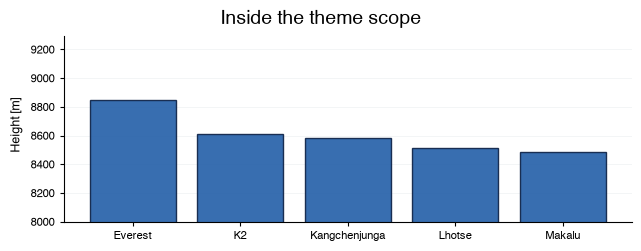

after: minimal


In [12]:
with config.using_theme(THEME.INK):
    print("inside:", config.theme)
    mountains("Inside the theme scope").show()

print("after:", config.theme)

The two nest in either order, each level restoring its own state. The scopes are plain save-and-restore on the global configuration, so they are neither thread-safe nor async-safe.

### Theme Files

`save_theme` writes a theme file: a JSON document carrying a name, a format version, and only the attributes that differ from the default theme, so the file stays short and reviewable. With no name it saves the live configuration, which lets a look assembled with `update_config` leave the process:

In [13]:
import tempfile
from pathlib import Path

folder = Path(tempfile.mkdtemp())
config.save_theme(folder / "house.json")
print((folder / "house.json").read_text())

{
    "name": "house",
    "format_version": 1,
    "attributes": {
        "color_general_multiple": "#B5651D",
        "color_parallel_hue_continuous": [
            "#D9D9D9",
            "#A9B4BE",
            "#6FA0F5",
            "#2B7FFF"
        ],
        "font_general_color": "#1F1F1F",
        "font_title_size": 16,
        "font_title_color": "#1F1F1F",
        "axes_spines_bottom_visible": false,
        "axes_spines_left_visible": false,
        "axes_ticks_length": 0,
        "plot_stackedarea_edge_width": 0,
        "plot_grid_alpha": 1.0,
        "plot_grid_color": "#EFEFEF",
        "plot_line_width": 2.0,
        "plot_bar_alpha": 1.0,
        "plot_bar_edge_width": 0,
        "plot_value_fontsize": 9,
        "plot_value_color": "#1F1F1F",
        "plot_hist_edge_width": 0,
        "plot_text_box_edgecolor": "#CFD8DC",
        "plot_text_arrow_color": "#9AA4AE",
        "plot_heatmap_frame_color": "#9AA4AE"
    }
}



A registered theme is saved by name:

In [14]:
config.save_theme(folder / "ink.json", name=THEME.INK)

`load_theme` registers the theme in a file and returns the name it registered under: the `name` argument, else the name in the file, else the file's stem. Loading only registers; apply the theme with `set_theme` or `using_theme`.

In [15]:
name = config.load_theme(folder / "house.json", name="house-v2")
config.set_theme(name)
config.theme, config["font_title_size"]

('house-v2', 16)

In [16]:
config.list_themes()

['default',
 'greyscale',
 'ink',
 'hatch',
 'minimal',
 'material',
 'sketch',
 'house-v2']

A file is validated the way `register_theme` validates a dictionary: missing attributes are filled from the default theme and an unknown attribute raises `ValueError`, so a hand-edited file cannot register a broken theme.

### Resetting

`reset_config` restores the default theme and resets the active theme name, discarding every override:

In [17]:
config.reset_config()
config.theme

'default'